<img src="https://res.cloudinary.com/dtizipxds/image/upload/q_auto/f_auto/v1776264397/banner_yvwajv.png" width="100%">


In [ ]:
%pip install -r ../requirements.txt


### 📋 Overview
2. Feature Engineering
3. Train-Test Split (Temporal) + **IQR Outlier Removal (train-set bounds only)**
2. Feature Engineering
3. Train-Test Split (Temporal)
4. Model Training
5. Model Evaluation (incl. Learning Curves & Diagnostics)
6. Feature Importance Analysis
7. Enhanced Model with cluster_id
8. Model Summary

---
## 1. 📦 Setup and Load Data

In [1]:
# ============================================================================
# IMPORTS AND CONFIGURATION
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Scikit-learn imports
from sklearn.model_selection import TimeSeriesSplit, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries imported successfully!")
print(f" Regression notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

All libraries imported successfully!
 Regression notebook started at: 2026-02-08 16:14:36


In [2]:
# Load preprocessed data
df_clean = pd.read_csv('../data/data_preprocessed.csv')
df_clean['created_at'] = pd.to_datetime(df_clean['created_at'], errors='coerce')

print(f"Preprocessed data loaded!")
print(f" Total records: {len(df_clean):,}")
print(f" Total columns: {len(df_clean.columns)}")
print(f" Date range: {df_clean['created_at'].min()} to {df_clean['created_at'].max()}")

Preprocessed data loaded!
 Total records: 16,283
 Total columns: 62
 Date range: 2018-11-27 08:27:31+00:00 to 2025-08-11 16:34:50+00:00


---
## 2. 🛠️ Feature Engineering

In [3]:
# ============================================================================
# TIME-SERIES DATA PREPARATION
# ============================================================================

print("=" * 80)
print("1. PREPARING TIME-SERIES DATA")
print("=" * 80)

# Sort by date (critical for time series)
df_model = df_clean.sort_values('created_at').copy()

# Feature engineering
df_model['is_pro'] = df_model['is_pro'].fillna(0).astype(int) if 'is_pro' in df_model.columns else 0
df_model['cpu_gen_brand'] = (
df_model['cpu_brand'].fillna('Unknown') + "_" +
df_model['cpu_generation'].fillna(0).astype(int).astype(str)
)

# Log transform RAM and SSD sizes (adding 1 to handle zeros)
df_model['RAM_SIZE_GB'] = np.log1p(df_model['RAM_SIZE_GB'])
df_model['SSD_SIZE_GB'] = np.log1p(df_model['SSD_SIZE_GB'])


print(f"Feature engineering complete")
print(f" • is_pro: {df_model['is_pro'].sum()} pro listings")
print(f" • cpu_gen_brand: {df_model['cpu_gen_brand'].nunique()} unique combinations")

1. PREPARING TIME-SERIES DATA
Feature engineering complete
 • is_pro: 695 pro listings
 • cpu_gen_brand: 26 unique combinations


In [4]:
# ============================================================================
# DEFINE FEATURES
# ============================================================================

feat_numeric = [
'RAM_SIZE_GB',
'SSD_SIZE_GB',
'cpu_mark',
'cpu_single_thread',
'gpu_score',
'build_quality_tier',
'condition_value_retention',
'cpu_generation',
'storage_perf_score',
'cpu_cores', 'inferred_ddr_ordinal', 'SCREEN_SIZE_NUM', 'cpu_threads'

]

feat_binary = ['is_pro', 'is_gaming_series', 'has_gpu']

feat_categorical = ['series', 'cpu_family', 'gpu_tier', 'condition', 'gpu_suffix', 'cpu_suffix', 'cpu_gen_brand','listing_year',
'brand',
'ram_type_class', 'resolution_class',
]

print(f" Feature Groups:")
print(f" feat_numeric: {feat_numeric}")
print(f" feat_binary: {feat_binary}")
print(f" feat_categorical: {feat_categorical}")
print(f"\n Total features: {len(feat_numeric) + len(feat_binary) + len(feat_categorical)}")

 Feature Groups:
 feat_numeric: ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_mark', 'cpu_single_thread', 'gpu_score', 'build_quality_tier', 'condition_value_retention', 'cpu_generation', 'storage_perf_score', 'cpu_cores', 'inferred_ddr_ordinal', 'SCREEN_SIZE_NUM', 'cpu_threads']
 feat_binary: ['is_pro', 'is_gaming_series', 'has_gpu']
 feat_categorical: ['series', 'cpu_family', 'gpu_tier', 'condition', 'gpu_suffix', 'cpu_suffix', 'cpu_gen_brand', 'listing_year', 'brand', 'ram_type_class', 'resolution_class']

 Total features: 27


In [5]:
# ============================================================================
# BUILD PREPROCESSOR
# ============================================================================

# Build preprocessor (EXACT structure from original)
preprocessor = ColumnTransformer(transformers=[
('num', Pipeline([('imp', SimpleImputer(strategy='mean')), ('scl', StandardScaler())]), feat_numeric),
('bin', 'passthrough', feat_binary),
('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), feat_categorical)
])

print("Preprocessor built (EXACT from original):")
print(" • Numeric: SimpleImputer(mean) → StandardScaler")
print(" • Binary: passthrough")
print(" • Categorical: OneHotEncoder(handle_unknown='ignore')")

Preprocessor built (EXACT from original):
 • Numeric: SimpleImputer(mean) → StandardScaler
 • Binary: passthrough
 • Categorical: OneHotEncoder(handle_unknown='ignore')


---
## 3. 📊 Train-Test Split (Temporal)

Perform temporal train-test split to simulate real-world prediction scenario:
- **Training set**: First 80% of data (earlier listings)
- **Test set**: Last 20% of data (more recent listings)

This ensures the model is evaluated on future data it hasn't seen during training.

In [6]:
# ============================================================================
# PREPARE DATA & TIME-BASED SPLIT
# ============================================================================

# Prepare data
X_raw = df_model[feat_numeric + feat_binary + feat_categorical]
y_raw = df_model['PRICES']
y_log = np.log1p(y_raw) # Log transform for better distribution

# Time-based split (80% train, 20% test)
split_idx = int(len(df_model) * 0.8)

X_train_raw = X_raw.iloc[:split_idx].copy()
X_test_raw = X_raw.iloc[split_idx:].copy()
y_train_raw = y_raw.iloc[:split_idx].copy()
y_train_log = y_log.iloc[:split_idx].copy()
y_test_log = y_log.iloc[split_idx:]
y_test_actual = y_raw.iloc[split_idx:]

# Indices for PassMark imputation and downstream steps
train_indices = X_train_raw.index
test_indices = X_test_raw.index

print(f" Time Split Index: {split_idx}")
print(f" Training Range: {df_model['created_at'].iloc[0].strftime('%Y-%m-%d')} → {df_model['created_at'].iloc[split_idx].strftime('%Y-%m-%d')}")
print(f" Testing Range: {df_model['created_at'].iloc[split_idx].strftime('%Y-%m-%d')} → {df_model['created_at'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"\n Training samples: {len(X_train_raw):,}")
print(f" Testing samples: {len(X_test_raw):,}")

 Time Split Index: 13026
 Training Range: 2018-11-27 → 2025-07-31
 Testing Range: 2025-07-31 → 2025-08-11

 Training samples: 13,026
 Testing samples: 3,257


### 3.0 Data-Driven PassMark Imputation

For CPUs and GPUs where PassMark matching failed in preprocessing, we now impute missing values using **data-driven tier medians** computed **from the training set only**.

**Why this approach prevents data leakage:**
- Medians are computed using ONLY training set rows that have actual PassMark matches
- These medians are then applied to both train and test sets
- Test set information never influences the imputation values

**Process:**
1. Identify rows in training set with successful PassMark matches
2. Group by performance tier (cpu_performance_class / gpu_performance_class)
3. Compute median scores per tier from matched rows only
4. Impute missing values in both train and test using these medians

In [7]:
# ============================================================================
# DATA-DRIVEN PASSMARK IMPUTATION
# ============================================================================

print("=" * 70)
print("DATA-DRIVEN PASSMARK IMPUTATION")
print("=" * 70)

# Get matching flag columns if they exist
cpu_matched_col = 'cpu_passmark_matched' if 'cpu_passmark_matched' in df_model.columns else None
gpu_matched_col = 'gpu_passmark_matched' if 'gpu_passmark_matched' in df_model.columns else None

# -------------------------------------------------------------------------
# CPU PASSMARK IMPUTATION
# -------------------------------------------------------------------------

if 'cpu_mark' in df_model.columns:
	# Get training set indices
	train_mask = df_model.index.isin(train_indices)

# Identify matched rows in training set
if cpu_matched_col:
	train_matched = train_mask & df_model[cpu_matched_col].fillna(False)
else:
	train_matched = train_mask & df_model['cpu_mark'].notna()

# Compute tier medians from TRAINING SET matched rows only
cpu_tier_medians = df_model[train_matched].groupby('cpu_performance_class').agg({
	'cpu_mark': 'median',
	'cpu_single_thread': 'median',
	'cpu_cores': 'median',
	'cpu_threads': 'median'
}).to_dict('index')

print("\n CPU Tier Medians (from training set matched rows):")
for tier, values in sorted(cpu_tier_medians.items()):
	n_samples = (df_model[train_matched]['cpu_performance_class'] == tier).sum()
	print(f" {tier:8s}: cpu_mark={values['cpu_mark']:,.0f}, single_thread={values['cpu_single_thread']:,.0f} (n={n_samples})")

# Count missing before imputation
cpu_missing_train = X_train_raw.index.isin(df_model[df_model['cpu_mark'].isna()].index).sum()
cpu_missing_test = X_test_raw.index.isin(df_model[df_model['cpu_mark'].isna()].index).sum()

# Impute missing values using tier medians
for tier, values in cpu_tier_medians.items():
	tier_mask = df_model['cpu_performance_class'] == tier
	for col, med_val in values.items():
		if col in df_model.columns and pd.notna(med_val):
			missing_mask = df_model[col].isna() & tier_mask
			df_model.loc[missing_mask, col] = med_val

# Update X_train_raw and X_test_raw with imputed values
for col in ['cpu_mark', 'cpu_single_thread', 'cpu_cores', 'cpu_threads']:
	if col in X_train_raw.columns:
		X_train_raw[col] = df_model.loc[train_indices, col].values
		X_test_raw[col] = df_model.loc[test_indices, col].values

print(f"\n CPU imputation complete:")
print(f" Train: {cpu_missing_train:,} rows imputed")
print(f" Test: {cpu_missing_test:,} rows imputed")

# -------------------------------------------------------------------------
# GPU PASSMARK IMPUTATION
# -------------------------------------------------------------------------

if 'gpu_score' in df_model.columns:
	# Identify matched rows in training set (exclude "None" GPUs which correctly have score=0)
	has_gpu = df_model['gpu_performance_class'] != 'None'
	if gpu_matched_col:
		train_matched_gpu = train_mask & df_model[gpu_matched_col].fillna(False) & has_gpu
	else:
		train_matched_gpu = train_mask & df_model['gpu_score'].notna() & (df_model['gpu_score'] > 0) & has_gpu

	# Compute tier medians from TRAINING SET matched rows only
	gpu_tier_medians = df_model[train_matched_gpu].groupby('gpu_performance_class')['gpu_score'].median().to_dict()

	print("\n GPU Tier Medians (from training set matched rows):")
	for tier, median_val in sorted(gpu_tier_medians.items()):
		n_samples = (df_model[train_matched_gpu]['gpu_performance_class'] == tier).sum()
		print(f" {tier:8s}: gpu_score={median_val:,.0f} (n={n_samples})")

	# Count missing before imputation (only for rows with GPUs)
	gpu_missing_mask = has_gpu & df_model['gpu_score'].isna()
	gpu_missing_train = (df_model.index.isin(train_indices) & gpu_missing_mask).sum()
	gpu_missing_test = (df_model.index.isin(test_indices) & gpu_missing_mask).sum()

	# Impute missing values using tier medians
	for tier, med_val in gpu_tier_medians.items():
		if pd.notna(med_val):
			tier_mask = (df_model['gpu_performance_class'] == tier) & df_model['gpu_score'].isna()
			df_model.loc[tier_mask, 'gpu_score'] = med_val

	# Update X_train_raw and X_test_raw with imputed values
	if 'gpu_score' in X_train_raw.columns:
		X_train_raw['gpu_score'] = df_model.loc[train_indices, 'gpu_score'].values
		X_test_raw['gpu_score'] = df_model.loc[test_indices, 'gpu_score'].values

	print(f"\n GPU imputation complete:")
	print(f" Train: {gpu_missing_train:,} rows imputed")
	print(f" Test: {gpu_missing_test:,} rows imputed")

print("\n" + "=" * 70)
print("Data-driven imputation complete - NO DATA LEAKAGE")
print(" Medians computed from TRAINING SET only, applied to both sets.")
print("=" * 70)

DATA-DRIVEN PASSMARK IMPUTATION

 CPU Tier Medians (from training set matched rows):
 High    : cpu_mark=22,995, single_thread=3,513 (n=1609)
 Low     : cpu_mark=3,203, single_thread=1,644 (n=1806)
 Medium  : cpu_mark=9,949, single_thread=2,617 (n=4582)
 Mid-Low : cpu_mark=6,069, single_thread=2,103 (n=3920)

 CPU imputation complete:
 Train: 1,109 rows imputed
 Test: 397 rows imputed

 GPU Tier Medians (from training set matched rows):
 High    : gpu_score=26,913 (n=340)
 Low     : gpu_score=2,826 (n=217)
 Medium  : gpu_score=17,190 (n=736)
 Mid-Low : gpu_score=9,499 (n=849)

 GPU imputation complete:
 Train: 69 rows imputed
 Test: 19 rows imputed

Data-driven imputation complete - NO DATA LEAKAGE
 Medians computed from TRAINING SET only, applied to both sets.


### 3.1 Outlier Removal

Same idea as before, to prevent data leakage: we compute IQR bounds **on the training set only** and apply them to filter both train and test sets. This ensures the model never sees test-set price distribution during training.

**Method:** For each GPU tier (or CPU family+generation for integrated-only), we compute:
- Lower bound: $Q_1 - 2 \times IQR$
- Upper bound: $Q_3 + 3 \times IQR$ (relaxed for *"JAMAIS UTILISÉ"*: $Q_3 + 6 \times IQR$)

Rows outside these bounds are flagged as noise and removed.

In [8]:
# ============================================================================
# OUTLIER REMOVAL:
# ============================================================================

print("=" * 70)
print("OUTLIER REMOVAL (IQR bounds from TRAINING SET only)")
print("=" * 70)

# Store original sizes
train_before = len(X_train_raw)
test_before = len(X_test_raw)

# Get indices for accessing df_model
train_indices = X_train_raw.index
test_indices = X_test_raw.index

def compute_iqr_bounds(df_subset, price_col='PRICES'):
	"""Compute IQR bounds from training subset only."""
	bounds = {}
	
	# Group by GPU tier (for listings with dedicated GPU)
	if 'gpu_performance_class' in df_subset.columns:
		for gpu_tier in df_subset['gpu_performance_class'].dropna().unique():
			mask = df_subset['gpu_performance_class'] == gpu_tier
			prices = df_subset.loc[mask, price_col]
			if len(prices) >= 10:
				Q1, Q3 = prices.quantile(0.25), prices.quantile(0.75)
				IQR = Q3 - Q1
				bounds[('gpu', gpu_tier)] = {
					'lower': Q1 - 2.0 * IQR,
					'upper_strict': Q3 + 3.0 * IQR,
					'upper_relaxed': Q3 + 6.0 * IQR
				}

	# Group by CPU family+gen for integrated-only listings
	if 'cpu_family' in df_subset.columns and 'cpu_generation' in df_subset.columns:
		no_gpu = df_subset['gpu_performance_class'].isna()
		for (fam, gen), group in df_subset[no_gpu].groupby(['cpu_family', 'cpu_generation']):
			prices = group[price_col]
			if len(prices) >= 5:
				Q1, Q3 = prices.quantile(0.25), prices.quantile(0.75)
				IQR = Q3 - Q1
				bounds[('cpu', fam, gen)] = {
					'lower': Q1 - 2.0 * IQR,
					'upper_strict': Q3 + 3.5 * IQR,
					'upper_relaxed': Q3 + 7.0 * IQR
				}

	return bounds

def apply_iqr_filter(df_subset, bounds, price_col='PRICES', condition_col='condition'):
	"""Apply IQR bounds. Returns boolean mask of rows to KEEP."""
	keep = pd.Series(True, index=df_subset.index)
	
	for key, b in bounds.items():
		if key[0] == 'gpu':
			gpu_tier = key[1]
			mask = df_subset['gpu_performance_class'] == gpu_tier
			if mask.sum() == 0:
				continue
			prices = df_subset.loc[mask, price_col]
			conditions = df_subset.loc[mask, condition_col] if condition_col in df_subset.columns else 'UNKNOWN'

			is_new = (conditions == 'JAMAIS UTILISÉ') if isinstance(conditions, pd.Series) else False
			upper = pd.Series(b['upper_strict'], index=prices.index)
			if isinstance(is_new, pd.Series):
				upper.loc[is_new] = b['upper_relaxed']

			noise = (prices < b['lower']) | (prices > upper)
			keep.loc[noise[noise].index] = False

		elif key[0] == 'cpu':
			fam, gen = key[1], key[2]
			mask = (df_subset['gpu_performance_class'].isna()) & \
				   (df_subset['cpu_family'] == fam) & \
				   (df_subset['cpu_generation'] == gen)
			if mask.sum() == 0:
				continue
			prices = df_subset.loc[mask, price_col]
			conditions = df_subset.loc[mask, condition_col] if condition_col in df_subset.columns else 'UNKNOWN'

			is_new = (conditions == 'JAMAIS UTILISÉ') if isinstance(conditions, pd.Series) else False
			upper = pd.Series(b['upper_strict'], index=prices.index)
			if isinstance(is_new, pd.Series):
				upper.loc[is_new] = b['upper_relaxed']

			noise = (prices < b['lower']) | (prices > upper)
			keep.loc[noise[noise].index] = False

	return keep

# Compute bounds from TRAINING data only
train_data = df_model.loc[train_indices].copy()
iqr_bounds = compute_iqr_bounds(train_data)
print(f"\n Computed {len(iqr_bounds)} group-specific IQR bounds from training set")

# Apply to BOTH train and test
train_keep = apply_iqr_filter(df_model.loc[train_indices], iqr_bounds)
test_keep = apply_iqr_filter(df_model.loc[test_indices], iqr_bounds)

# Filter all related variables
X_train_raw = X_train_raw.loc[train_keep]
y_train_raw = y_train_raw.loc[train_keep]
y_train_log = y_train_log.loc[train_keep]

X_test_raw = X_test_raw.loc[test_keep]
y_test_log = y_test_log.loc[test_keep]
y_test_actual = y_test_actual.loc[test_keep]

train_after = len(X_train_raw)
test_after = len(X_test_raw)

print(f"\n Training set: {train_before:,} → {train_after:,} ({train_before - train_after} outliers removed)")
print(f" Test set: {test_before:,} → {test_after:,} ({test_before - test_after} outliers removed)")
print(f"\nIQR bounds computed on TRAINING SET ONLY (no data leakage)")
print(f" Same bounds applied to filter both train and test sets")

OUTLIER REMOVAL (IQR bounds from TRAINING SET only)

 Computed 66 group-specific IQR bounds from training set

 Training set: 13,026 → 12,916 (110 outliers removed)
 Test set: 3,257 → 3,250 (7 outliers removed)

IQR bounds computed on TRAINING SET ONLY (no data leakage)
 Same bounds applied to filter both train and test sets


In [9]:
# Transform data using preprocessor
X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

print(f"Data transformed")
print(f" X_train_proc shape: {X_train_proc.shape}")
print(f" X_test_proc shape: {X_test_proc.shape}")

Data transformed
 X_train_proc shape: (12916, 192)
 X_test_proc shape: (3250, 192)


---
## 4. Model Training

In [10]:
# ============================================================================
# TRAIN MULTIPLE MODELS
# ============================================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

print("=" * 80)
print("MULTI-MODEL TRAINING")
print("=" * 80)

# Dictionary to store models and their names
models = {
	"LinearRegression": LinearRegression(),
	"Ridge": Ridge(alpha=1.0, random_state=42),
	"Lasso": Lasso(alpha=0.01, random_state=42),
	"RandomForest": RandomForestRegressor(
		n_estimators=300, max_depth=10, random_state=42, n_jobs=-1
	),
	"GradientBoosting": GradientBoostingRegressor(
		n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42
	),
	"SVR": SVR(C=10, gamma='scale', epsilon=0.1)
}

# Dictionary to store fitted models and their R² on training data
trained_models = {}
r2_train = {}

# Train all models
for name, model in models.items():
	print(f"\n Training {name}")
	model.fit(X_train_proc, y_train_log)
	trained_models[name] = model
	y_pred_train = model.predict(X_train_proc)
	r2 = r2_score(y_train_log, y_pred_train)
	r2_train[name] = r2
	print(f"{name} training complete! | Training R²: {r2:.4f}")

# Summary of results
print("\n" + "="*40 + " TRAINING R² SUMMARY " + "="*40)
for name, r2 in r2_train.items():
	print(f"{name:<20} -> R²: {r2:.4f}")

MULTI-MODEL TRAINING

 Training LinearRegression
LinearRegression training complete! | Training R²: 0.8146

 Training Ridge
Ridge training complete! | Training R²: 0.8133

 Training Lasso
Lasso training complete! | Training R²: 0.7135

 Training RandomForest
RandomForest training complete! | Training R²: 0.8636

 Training GradientBoosting
GradientBoosting training complete! | Training R²: 0.9110

 Training SVR
SVR training complete! | Training R²: 0.9381

======================================== TRAINING R² SUMMARY ========================================
LinearRegression     -> R²: 0.8146
Ridge                -> R²: 0.8133
Lasso                -> R²: 0.7135
RandomForest         -> R²: 0.8636
GradientBoosting     -> R²: 0.9110
SVR                  -> R²: 0.9381


In [11]:
# ============================================================================
# PREDICT AND EVALUATE ALL MODELS
# ============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
import numpy as np

print("\n" + "=" * 80)
print(" MODEL EVALUATION (Temporal Split)")
print("=" * 80)

# Dictionary to store test metrics
test_metrics = {}

# Evaluate each trained model
for name, model in trained_models.items():
    print(f"\n Evaluating {name}")

    # Predict (log scale) and convert back
    y_pred_log = model.predict(X_test_proc)
    y_pred_temp = np.expm1(y_pred_log)

    # Compute metrics
    r2_temp = r2_score(y_test_actual, y_pred_temp)
    mae_temp = mean_absolute_error(y_test_actual, y_pred_temp)
    rmse_temp = np.sqrt(mean_squared_error(y_test_actual, y_pred_temp))
    mape_temp = mean_absolute_percentage_error(y_test_actual, y_pred_temp)

    test_metrics[name] = {
        "R²": r2_temp,
        "MAE": mae_temp,
        "RMSE": rmse_temp,
        "MAPE": mape_temp
    }

    print(f" R² Score: {r2_temp:.4f} ({r2_temp * 100:.1f}% variance explained)")
    print(f" MAE: {mae_temp:,.0f} DZD")
    print(f" RMSE: {rmse_temp:,.0f} DZD")
    print(f" MAPE: {mape_temp * 100:.2f}%")

# --- Comparison Summary ---
print("\n" + "=" * 60)
print(" MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'R²':<10} {'MAE (DZD)':<15} {'RMSE':<10} {'MAPE':<10}")
print("-" * 60)

for name, metrics in test_metrics.items():
    print(
        f"{name:<25} "
        f"{metrics['R²']:.4f} "
        f"{metrics['MAE']:,.0f} "
        f"{metrics['RMSE']:,.0f} "
        f"{metrics['MAPE'] * 100:.2f}%"
    )

print("-" * 60)

# Keep reference to the best model (highest R²)
best_model_name = max(test_metrics, key=lambda x: test_metrics[x]["R²"])
best_model = trained_models[best_model_name]
print(
    f"\n Best model: {best_model_name} | "
    f"Test R²: {test_metrics[best_model_name]['R²']:.4f}"
)

# Set y_pred and metrics from the BEST MODEL for downstream diagnostics
y_pred_log = best_model.predict(X_test_proc)
y_pred = np.expm1(y_pred_log)
r2 = test_metrics[best_model_name]["R²"]
mae = test_metrics[best_model_name]["MAE"]
rmse = test_metrics[best_model_name]["RMSE"]
mape_val = test_metrics[best_model_name]["MAPE"]

print(f"\n Variables y_pred, r2, mae, rmse, mape_val now set from: {best_model_name}")


 MODEL EVALUATION (Temporal Split)

 Evaluating LinearRegression
 R² Score: 0.8487 (84.9% variance explained)
 MAE: 21,745 DZD
 RMSE: 39,174 DZD
 MAPE: 18.28%

 Evaluating Ridge
 R² Score: 0.8586 (85.9% variance explained)
 MAE: 21,630 DZD
 RMSE: 37,876 DZD
 MAPE: 18.22%

 Evaluating Lasso
 R² Score: 0.7567 (75.7% variance explained)
 MAE: 29,191 DZD
 RMSE: 49,675 DZD
 MAPE: 23.50%

 Evaluating RandomForest
 R² Score: 0.8882 (88.8% variance explained)
 MAE: 19,205 DZD
 RMSE: 33,670 DZD
 MAPE: 16.79%

 Evaluating GradientBoosting
 R² Score: 0.9013 (90.1% variance explained)
 MAE: 17,678 DZD
 RMSE: 31,638 DZD
 MAPE: 15.17%

 Evaluating SVR
 R² Score: 0.8879 (88.8% variance explained)
 MAE: 19,194 DZD
 RMSE: 33,721 DZD
 MAPE: 16.36%

 MODEL COMPARISON SUMMARY
Model                     R²         MAE (DZD)       RMSE       MAPE      
------------------------------------------------------------
LinearRegression          0.8487 21,745 39,174 18.28%
Ridge                     0.8586 21,630 37

---
### Learning Curves

**Learning curves** plot **train and validation score vs. training set size**. They help diagnose:
- **Underfitting**: both curves low → model too simple or need more features.
- **Overfitting**: train score high, validation score lower with a gap → model memorizing training data; consider regularization or more data.
- **Good fit**: train and validation converge to a similar level as data increases.

We use **time-based splits** (first 80% train) and vary the training size to see how performance evolves. The metric is **R²** on the **log-price** scale (same as the model target).

LEARNING CURVES: LINEAR REGRESSION vs GRADIENT BOOSTING vs SVR (TIME-AWARE)


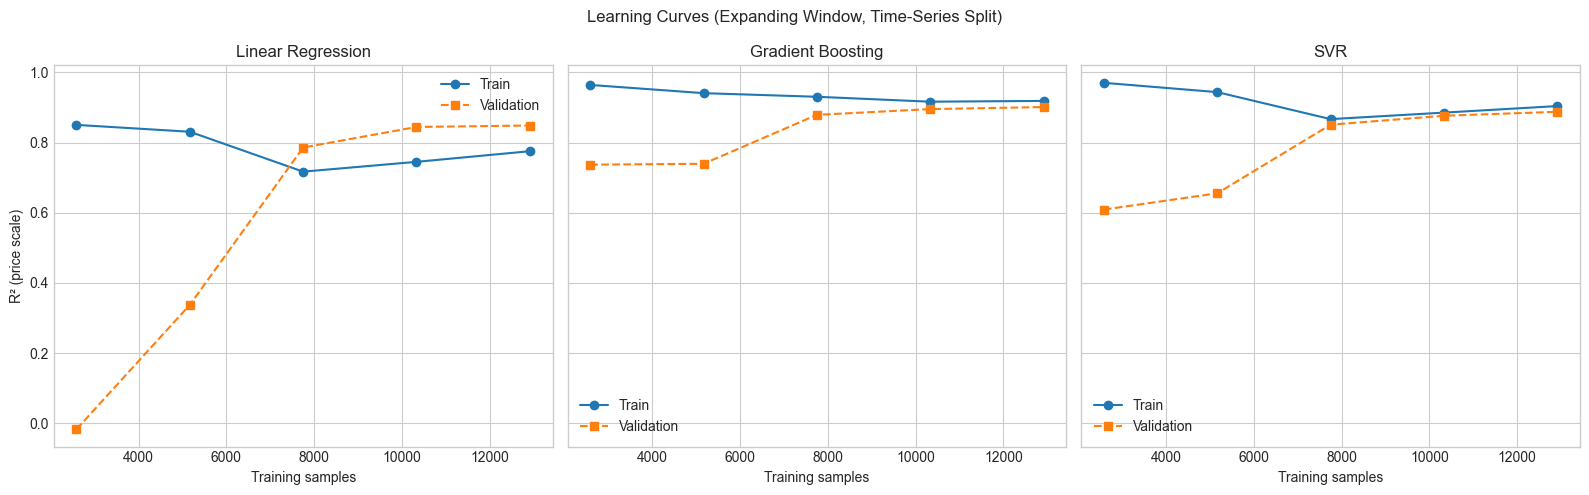

In [12]:
# ============================================================================
# LEARNING CURVES — LINEAR REGRESSION vs GRADIENT BOOSTING vs SVR (TIME SERIES)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

print("=" * 80)
print("LEARNING CURVES: LINEAR REGRESSION vs GRADIENT BOOSTING vs SVR (TIME-AWARE)")
print("=" * 80)

# Fractions of the TRAINING PERIOD (expanding window)
train_fracs = np.linspace(0.2, 1.0, 5)  # 20% → 100%

# Containers
train_sizes = []

lr_train_scores, lr_val_scores = [], []
gb_train_scores, gb_val_scores = [], []
svr_train_scores, svr_val_scores = [], []

# Fixed test set (future)
X_val = X_test_proc
y_val = y_test_actual  # original price scale

for frac in train_fracs:
    n_train = max(100, int(len(X_train_proc) * frac))
    train_sizes.append(n_train)

    # Expanding-window subset (PAST ONLY)
    X_sub = X_train_proc[:n_train]
    y_sub_log = y_train_log.iloc[:n_train]
    y_sub = y_train_raw.iloc[:n_train]

    # ------------------------------------------------------------------
    # Linear Regression
    # ------------------------------------------------------------------
    lr = LinearRegression()
    lr.fit(X_sub, y_sub_log)

    lr_train_scores.append(
        r2_score(y_sub, np.expm1(lr.predict(X_sub)))
    )
    lr_val_scores.append(
        r2_score(y_val, np.expm1(lr.predict(X_val)))
    )

    # ------------------------------------------------------------------
    # Gradient Boosting
    # ------------------------------------------------------------------
    gb = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42
    )
    gb.fit(X_sub, y_sub_log)

    gb_train_scores.append(
        r2_score(y_sub, np.expm1(gb.predict(X_sub)))
    )
    gb_val_scores.append(
        r2_score(y_val, np.expm1(gb.predict(X_val)))
    )

    # ------------------------------------------------------------------
    # Support Vector Regressor (SVR)
    # ------------------------------------------------------------------
    svr = SVR(kernel='rbf', C=10, epsilon=0.1)
    svr.fit(X_sub, y_sub_log)

    svr_train_scores.append(
        r2_score(y_sub, np.expm1(svr.predict(X_sub)))
    )
    svr_val_scores.append(
        r2_score(y_val, np.expm1(svr.predict(X_val)))
    )

# ============================================================================
# PLOTTING — 3 SUBPLOTS SIDE BY SIDE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

# --- Linear Regression ---
axes[0].plot(train_sizes, lr_train_scores, marker='o', label='Train')
axes[0].plot(train_sizes, lr_val_scores, marker='s', linestyle='--', label='Validation')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Training samples')
axes[0].set_ylabel('R² (price scale)')
axes[0].grid(True)
axes[0].legend()

# --- Gradient Boosting ---
axes[1].plot(train_sizes, gb_train_scores, marker='o', label='Train')
axes[1].plot(train_sizes, gb_val_scores, marker='s', linestyle='--', label='Validation')
axes[1].set_title('Gradient Boosting')
axes[1].set_xlabel('Training samples')
axes[1].grid(True)
axes[1].legend()

# --- SVR ---
axes[2].plot(train_sizes, svr_train_scores, marker='o', label='Train')
axes[2].plot(train_sizes, svr_val_scores, marker='s', linestyle='--', label='Validation')
axes[2].set_title('SVR')
axes[2].set_xlabel('Training samples')
axes[2].grid(True)
axes[2].legend()

plt.suptitle('Learning Curves (Expanding Window, Time-Series Split)', fontsize=12)
plt.tight_layout()
plt.show()

Based on the learning curves, we can say that:
    - **Linear Regression:** underfitted
    - **Gradient Boosting** and **SVR**: had a healthy learning curve

---
## 5. Model Evaluation

We evaluate on the **temporal test set** (last 20% of data). The **Actual vs. Predicted** scatter should cluster around the diagonal; the **residual histogram** should be centered near zero. Learning curves and full diagnostics (Q-Q, residual vs. fitted, percentage error) follow below.

---
### Model Diagnostics (Residuals)

We check **residual assumptions** for regression:
- **Q-Q plot**: Residuals vs. theoretical quantiles of a normal distribution. Points along the diagonal suggest roughly normal errors; heavy tails or skew indicate non-normality.
- **Residual vs. fitted**: Residuals should be centered around zero with roughly constant spread (homoscedasticity). Funneling or patterns suggest heteroscedasticity or missing structure.
- **Percentage error distribution**: How often predictions are within 10%, 20%, etc. of the actual price; useful for business interpretation.

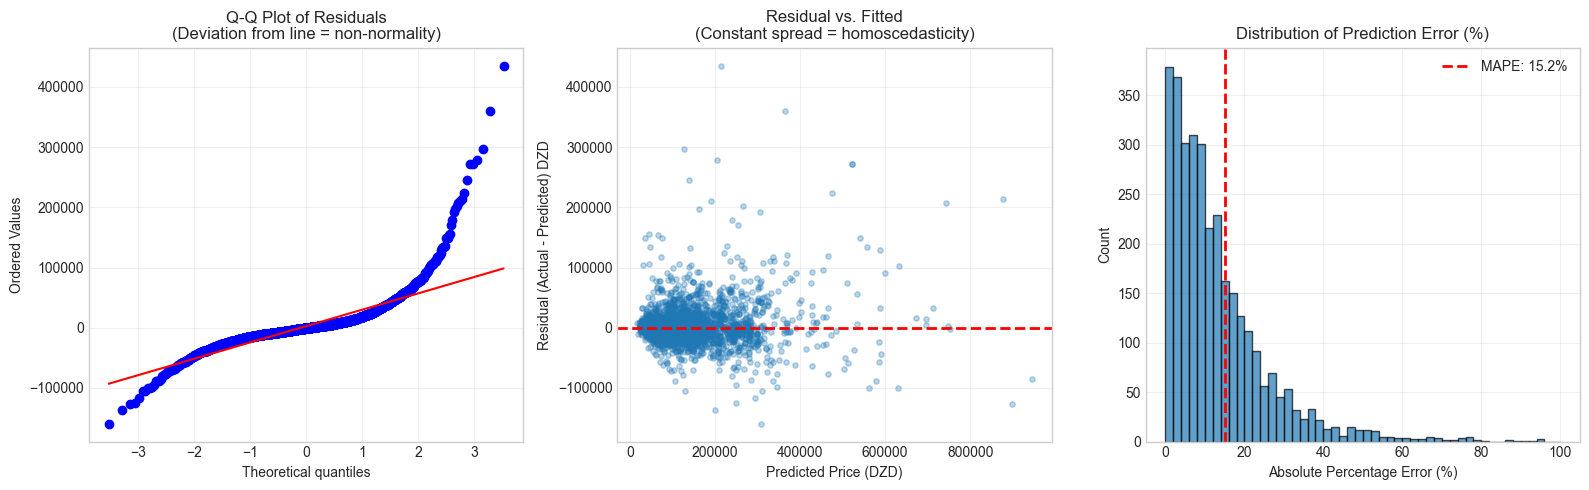

 Within 10% error: 51.1% of test samples
 Within 15% error: 67.4% of test samples
 Within 20% error: 78.3% of test samples
 Within 25% error: 85.4% of test samples
 Within 30% error: 89.8% of test samples


In [13]:
# ============================================================================
# MODEL DIAGNOSTICS: Q-Q PLOT, RESIDUAL VS FITTED, PERCENTAGE ERROR
# ============================================================================
from scipy import stats as scipy_stats

residuals = y_test_actual.values - y_pred # y_pred from evaluation cell
pct_errors = np.abs((y_test_actual.values - y_pred) / (y_test_actual.values + 1e-6)) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Q-Q plot of residuals
scipy_stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot of Residuals\n(Deviation from line = non-normality)')
axes[0].grid(True, alpha=0.3)

# Residual vs. fitted (predicted)
axes[1].scatter(y_pred, residuals, alpha=0.3, s=15)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price (DZD)')
axes[1].set_ylabel('Residual (Actual - Predicted) DZD')
axes[1].set_title('Residual vs. Fitted\n(Constant spread = homoscedasticity)')
axes[1].grid(True, alpha=0.3)

# Percentage error distribution
axes[2].hist(pct_errors, bins=50, edgecolor='black', alpha=0.7, range=(0, 100))
axes[2].axvline(mape_val * 100, color='red', linestyle='--', linewidth=2, label=f'MAPE: {mape_val*100:.1f}%')
axes[2].set_xlabel('Absolute Percentage Error (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('Distribution of Prediction Error (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Summary: share of predictions within X% error
for thresh in [10, 15, 20, 25, 30]:
    pct_within = (pct_errors <= thresh).mean() * 100
    print(f" Within {thresh}% error: {pct_within:.1f}% of test samples")

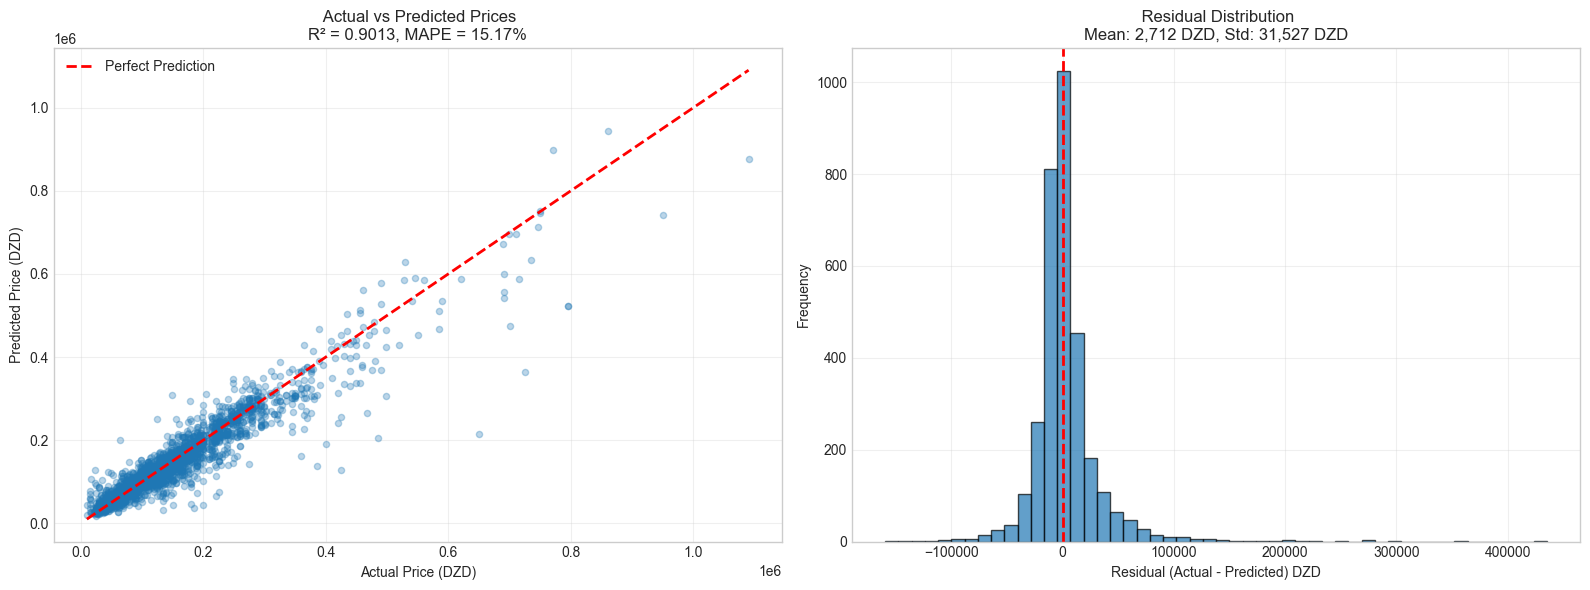

In [14]:
# ============================================================================
# VISUALIZATION: ACTUAL VS PREDICTED
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Scatter plot
axes[0].scatter(y_test_actual, y_pred, alpha=0.3, s=20)
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
[y_test_actual.min(), y_test_actual.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price (DZD)')
axes[0].set_ylabel('Predicted Price (DZD)')
axes[0].set_title(f' Actual vs Predicted Prices\nR² = {r2:.4f}, MAPE = {mape_val*100:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_actual - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted) DZD')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f' Residual Distribution\nMean: {residuals.mean():,.0f} DZD, Std: {residuals.std():,.0f} DZD')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Feature Importance Analysis

In [15]:
# ============================================================================
# EXTRACT FEATURE NAMES AND IMPORTANCES
# ============================================================================

# Get feature names after preprocessing
num_features = feat_numeric.copy()
bin_features = feat_binary.copy()

# Get categorical feature names (one-hot encoded)
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(feat_categorical).tolist()

# Combine all feature names
all_feature_names = num_features + bin_features + cat_features

# Get feature importances (tree/ensemble have feature_importances_; linear/SVR have coef_)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_') and best_model.coef_ is not None:
    importances = np.abs(best_model.coef_).ravel()
    if len(importances) != len(all_feature_names):
        importances = np.zeros(len(all_feature_names))  # fallback if shape mismatch
else:
    importances = np.zeros(len(all_feature_names))
    print(f" Feature importance not available for {type(best_model).__name__}; showing zeros.")

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(f" Total features after encoding: {len(all_feature_names)}")
print(f"\n Top 20 Most Important Features:")
print(importance_df.head(20).to_string(index=False))

 Total features after encoding: 192

 Top 20 Most Important Features:
                  Feature  Importance
                 cpu_mark        0.37
        cpu_single_thread        0.09
              SSD_SIZE_GB        0.07
              RAM_SIZE_GB        0.06
     inferred_ddr_ordinal        0.06
    cpu_gen_brand_APPLE_0        0.05
                gpu_score        0.04
           cpu_generation        0.03
condition_value_retention        0.02
                cpu_cores        0.02
 condition_JAMAIS UTILISÉ        0.02
          SCREEN_SIZE_NUM        0.01
           cpu_suffix_nan        0.01
              brand_APPLE        0.01
                  has_gpu        0.01
        listing_year_2021        0.01
        listing_year_2022        0.01
        listing_year_2025        0.01
        listing_year_2024        0.01
            cpu_family_i5        0.00


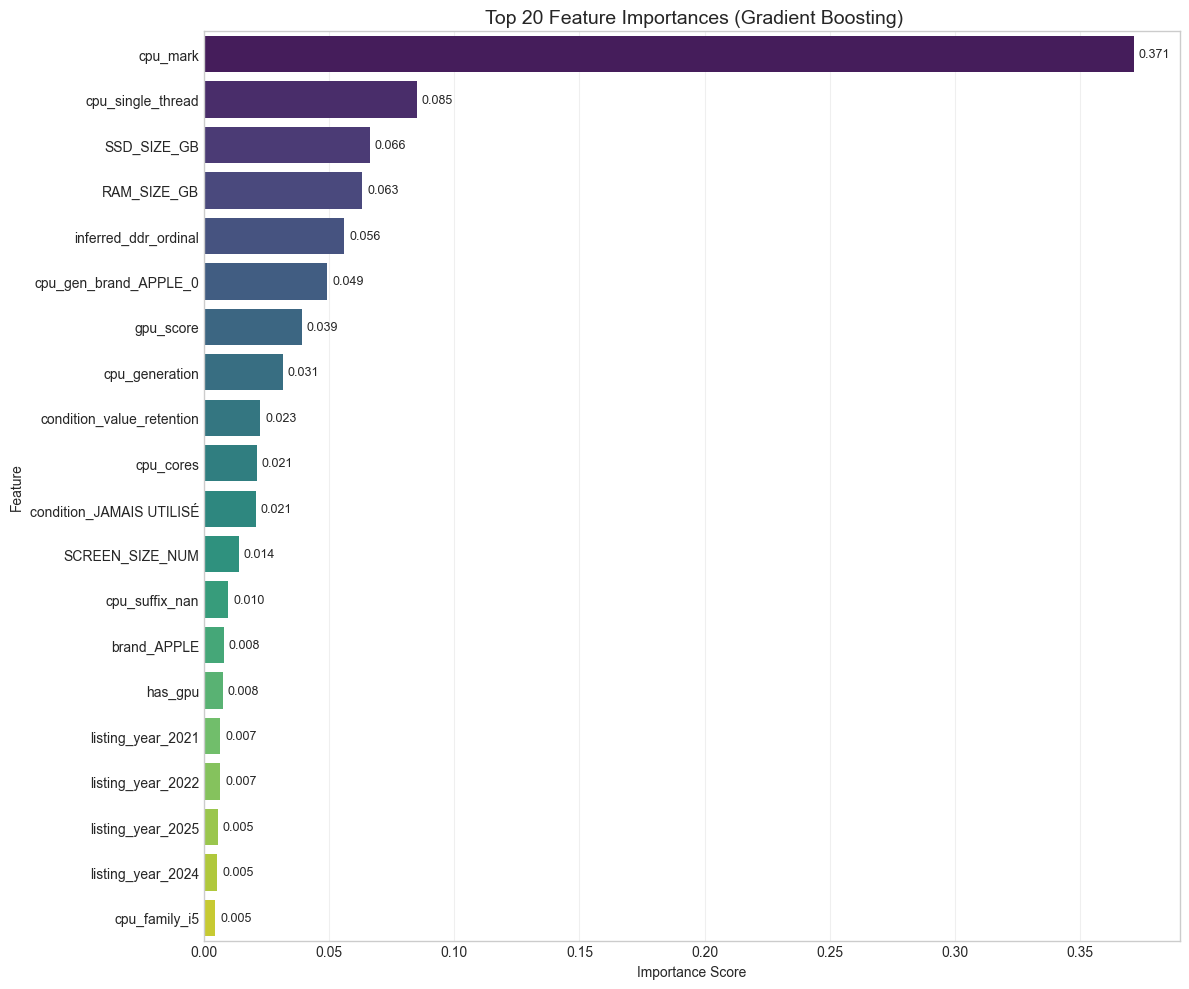

In [16]:
# Visualize feature importance
plt.figure(figsize=(12, 10))
top_20 = importance_df.head(20)
sns.barplot(data=top_20, x='Importance', y='Feature', palette='viridis')
plt.title(' Top 20 Feature Importances (Gradient Boosting)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_20['Importance']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.0 SHAP values (model explainability)

**SHAP** (SHapley Additive exPlanations) assigns each feature a contribution per prediction (how much it pushed price up or down). Unlike global feature importance, SHAP shows **direction** (positive vs negative) and **distribution** of effects.

- We use **TreeExplainer** (fast and exact for Gradient Boosting).
- We sample the training set for the background and a subset of test for the summary plot to keep runtime reasonable.
- **Summary plot (beeswarm)**: each dot = one observation; horizontal position = SHAP value (impact on log-price); color = feature value (e.g. high vs low).
- **Bar plot**: mean |SHAP| = overall importance, consistent with the model’s own feature importance.

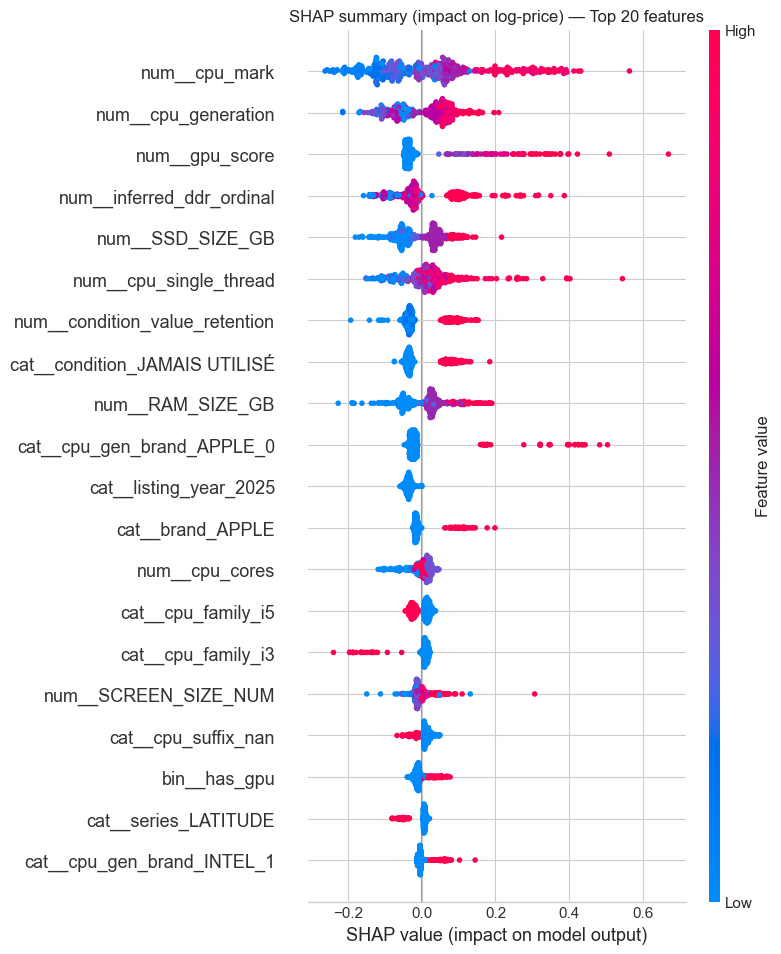

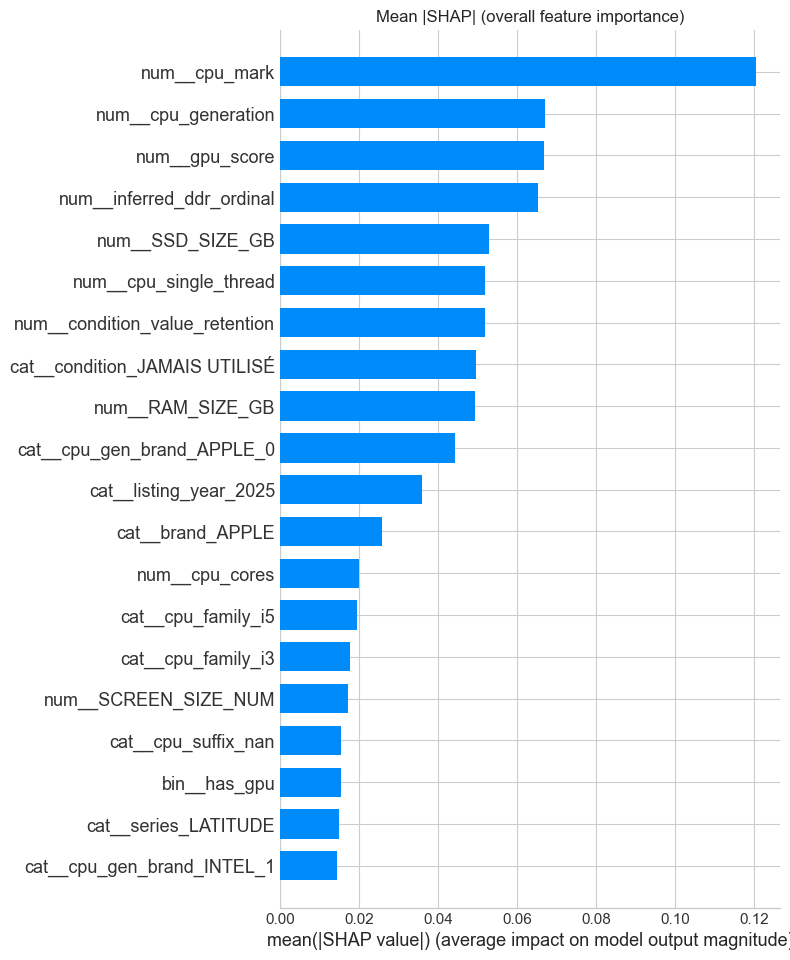

In [19]:
# ============================================================================
# SHAP VALUES (TreeExplainer for Gradient Boosting)
# ============================================================================

try:
    import shap
except ImportError:
    print("SHAP not installed. Run: pip install shap")
    raise

# Use SHAP only for tree-based best model (TreeExplainer is fast and exact)
tree_models = ('GradientBoosting')
if best_model_name in tree_models:
    # Sample for speed (SHAP on full set can be slow)
    n_background = 500
    n_explain = 500
    rng = np.random.RandomState(42)
    ix_back = rng.choice(len(X_train_proc), size=min(n_background, len(X_train_proc)), replace=False)
    ix_test = rng.choice(len(X_test_proc), size=min(n_explain, len(X_test_proc)), replace=False)
    X_back = X_train_proc[ix_back]
    X_explain = X_test_proc[ix_test]

    explainer = shap.TreeExplainer(best_model, X_back)
    shap_values = explainer.shap_values(X_explain)

    feature_names = preprocessor.get_feature_names_out()

    # Beeswarm: each dot = one observation; x = SHAP (impact on log-price), color = feature value
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False, max_display=20)
    plt.tight_layout()
    plt.title('SHAP summary (impact on log-price) — Top 20 features')
    plt.show()

    # Bar: mean |SHAP| = overall importance
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type='bar', show=False, max_display=20)
    plt.tight_layout()
    plt.title('Mean |SHAP| (overall feature importance)')
    plt.show()
else:
    print(f"SHAP TreeExplainer skipped (best model is {best_model_name}; use tree-based model for SHAP).")

---
## 6.1 Enhanced Model with Market Segments (cluster_id)

We extend the regression by **adding K-Means cluster_id** as a feature. This captures latent market segments (budget, mid-range, premium, gaming) that have different pricing logics.

**Design:**
1. **K-Means fitted on training set only** (configuration features, no price)
2. **Test set assigned to nearest training centroid** (no re-fitting)
3. **cluster_id treated as categorical feature** in both Linear Regression and Gradient Boosting

This allows models to learn **segment-specific pricing patterns** while preserving temporal split integrity.

In [ ]:
# ============================================================================
# ENHANCED REGRESSION WITH CLUSTER_ID (K-MEANS ON TRAINING SET ONLY)
# ============================================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

print("=" * 70)
print("ENHANCED MODEL WITH MARKET SEGMENTS (cluster_id)")
print("=" * 70)

# Map performance classes to ordinal values (if not already done)
cpu_class_map = {'Low': 1, 'Mid-Low': 2, 'Medium': 3, 'High': 4}
gpu_class_map = {'Low': 1, 'Mid-Low': 2, 'Medium': 3, 'High': 4}

if 'cpu_class_ordinal' not in df_model.columns:
    df_model['cpu_class_ordinal'] = df_model['cpu_performance_class'].map(cpu_class_map).fillna(0)
if 'gpu_class_ordinal' not in df_model.columns:
    df_model['gpu_class_ordinal'] = df_model['gpu_performance_class'].map(gpu_class_map).fillna(0)

# ----------------------------------------------------------------------------
# LOCAL FEATURE GEN: screen_pixels (if missing)
# ----------------------------------------------------------------------------
if 'screen_pixels' not in df_model.columns and 'SCREEN_RESOLUTION' in df_model.columns:
    import re
    def get_pixels_local(x):
        try:
            match = re.search(r'(\d{3,4})\s*[xX]\s*(\d{3,4})', str(x))
            if match:
                return int(match.group(1)) * int(match.group(2))
            return 0 # Default/Fallback
        except:
            return 0
    df_model['screen_pixels'] = df_model['SCREEN_RESOLUTION'].apply(get_pixels_local)
    print("Generated screen_pixels locally for clustering.")

# Configuration features for clustering
cluster_feature_cols = ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_class_ordinal', 'cpu_generation']

# Add optional features if they exist
optional_features = ['gpu_class_ordinal', 'condition_value_retention', 'inferred_ddr_ordinal', 
                     'cpu_mark', 'gpu_score', 'screen_pixels']
for f in optional_features:
    if f in df_clean.columns:
        cluster_feature_cols.append(f)

print(f"\nCluster features: {cluster_feature_cols}")

# Prepare clustering data (using indices from IQR-filtered train/test)
train_idx = X_train_raw.index
test_idx = X_test_raw.index

X_cluster_train = df_model.loc[train_idx, cluster_feature_cols].fillna(0)
X_cluster_test = df_model.loc[test_idx, cluster_feature_cols].fillna(0)

# Scale using training data only
cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_test_scaled = cluster_scaler.transform(X_cluster_test)

# Fit K-Means on TRAINING SET ONLY (K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_cluster_train_scaled)

# Assign clusters
cluster_train = kmeans.predict(X_cluster_train_scaled)
cluster_test = kmeans.predict(X_cluster_test_scaled)

print(f"\n Cluster distribution (training):")
for c in range(optimal_k):
    print(f" Cluster {c}: {(cluster_train == c).sum():,} samples")

# ---------------------------------------------------------------------------
# TRAIN MODELS WITH cluster_id
# ---------------------------------------------------------------------------

# Add cluster_id to feature sets (one-hot encoded)
X_train_with_cluster = X_train_proc.copy()
X_test_with_cluster = X_test_proc.copy()

for c in range(optimal_k):
    X_train_with_cluster = np.column_stack([X_train_with_cluster, (cluster_train == c).astype(int)])
    X_test_with_cluster = np.column_stack([X_test_with_cluster, (cluster_test == c).astype(int)])

print(f"\n Features: {X_train_proc.shape[1]} → {X_train_with_cluster.shape[1]} (with cluster dummies)")

# Train Gradient Boosting with cluster_id
gb_with_cluster = GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
gb_with_cluster.fit(X_train_with_cluster, y_train_log)
y_pred_log_cluster = gb_with_cluster.predict(X_test_with_cluster)
y_pred_cluster = np.expm1(y_pred_log_cluster)

# Train Linear Regression with cluster_id
lr_with_cluster = LinearRegression()
lr_with_cluster.fit(X_train_with_cluster, y_train_log)
y_pred_log_lr = lr_with_cluster.predict(X_test_with_cluster)
y_pred_lr = np.expm1(y_pred_log_lr)

# Calculate metrics
from sklearn.metrics import mean_absolute_percentage_error

r2_gb_cluster = r2_score(y_test_actual, y_pred_cluster)
mae_gb_cluster = mean_absolute_error(y_test_actual, y_pred_cluster)
mape_gb_cluster = mean_absolute_percentage_error(y_test_actual, y_pred_cluster) * 100

r2_lr_cluster = r2_score(y_test_actual, y_pred_lr)
mae_lr_cluster = mean_absolute_error(y_test_actual, y_pred_lr)
mape_lr_cluster = mean_absolute_percentage_error(y_test_actual, y_pred_lr) * 100

print("\n" + "=" * 70)
print("MODEL COMPARISON: WITH vs WITHOUT cluster_id")
print("=" * 70)

print("\n GRADIENT BOOSTING:")
print(f" Without cluster_id: R²={r2:.4f}, MAE={mae:,.0f} DZD, MAPE={mape_val:.1f}%")
print(f" With cluster_id: R²={r2_gb_cluster:.4f}, MAE={mae_gb_cluster:,.0f} DZD, MAPE={mape_gb_cluster:.1f}%")
r2_improvement_gb = (r2_gb_cluster - r2) / abs(r2) * 100 if r2 != 0 else 0
print(f" → R² change: {r2_improvement_gb:+.2f}%")

print("\n LINEAR REGRESSION (with cluster_id):")
print(f" R²={r2_lr_cluster:.4f}, MAE={mae_lr_cluster:,.0f} DZD, MAPE={mape_lr_cluster:.1f}%")
print(" (Linear Regression benefits more from cluster as it can't learn interactions)")

ENHANCED MODEL WITH MARKET SEGMENTS (cluster_id)

Cluster features: ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_class_ordinal', 'cpu_generation', 'condition_value_retention', 'inferred_ddr_ordinal', 'cpu_mark', 'gpu_score', 'screen_pixels']

 Cluster distribution (training):
 Cluster 0: 4,574 samples
 Cluster 1: 1,137 samples
 Cluster 2: 5,615 samples
 Cluster 3: 1,590 samples

 Features: 192 → 196 (with cluster dummies)

MODEL COMPARISON: WITH vs WITHOUT cluster_id

 GRADIENT BOOSTING:
 Without cluster_id: R²=0.9013, MAE=17,678 DZD, MAPE=0.2%
 With cluster_id: R²=0.8969, MAE=18,217 DZD, MAPE=15.6%
 → R² change: -0.49%

 LINEAR REGRESSION (with cluster_id):
 R²=0.8505, MAE=21,673 DZD, MAPE=18.2%
 (Linear Regression benefits more from cluster as it can't learn interactions)


**Takeaway:** Adding `cluster_id` (K-Means segments) as a feature allows the model to learn **segment-specific pricing patterns**. There was no improvement for Gradient Boosting (which can already learn non-linear interactions), it just made it a bit more complex, but more significant for Linear Regression. The key benefit is **interpretability**: we can now explain predictions in terms of market segments (e.g., "this laptop is in the Premium segment where CPU matters more than GPU").

---
## 7. Model Summary

In [ ]:
# ============================================================================
# FINAL MODEL SUMMARY
# ============================================================================
# Use the BEST model's test metrics (same as "Best model: ... | Test R²: ...")
r2 = test_metrics[best_model_name]["R²"]
mae = test_metrics[best_model_name]["MAE"]
rmse = test_metrics[best_model_name]["RMSE"]
mape_val = test_metrics[best_model_name]["MAPE"]

print("=" * 80)
print(" REGRESSION MODEL SUMMARY")
print("=" * 80)

print(f"\n MODEL: {best_model_name}")
print(f" • Target: log1p(PRICES)")

print(f"\n FEATURES USED:")
print(f" • Numeric: {feat_numeric}")
print(f" • Binary: {feat_binary}")
print(f" • Categorical: {feat_categorical}")

print(f"\n PERFORMANCE METRICS (test set):")
print(f" • R² Score: {r2:.4f} ({r2*100:.1f}% variance explained)")
print(f" • MAPE: {mape_val*100:.2f}%")
print(f" • MAE: {mae:,.0f} DZD")
print(f" • RMSE: {rmse:,.0f} DZD")

print(f"\n DATA SPLIT (TEMPORAL):")
print(f" • Training: {len(X_train_raw):,} samples (80%)")
print(f" • Testing: {len(X_test_raw):,} samples (20%)")

print(f"\n TOP 5 PRICE DRIVERS:")
for idx, (i, row) in enumerate(importance_df.head(5).iterrows(), 1):
	print(f" {idx}. {row['Feature']}: {row['Importance']:.4f}")

print("\n" + "=" * 80)
print("REGRESSION ANALYSIS COMPLETE")
print("=" * 80)

 REGRESSION MODEL SUMMARY

 MODEL: GradientBoosting
 • Target: log1p(PRICES)

 FEATURES USED:
 • Numeric: ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_mark', 'cpu_single_thread', 'gpu_score', 'build_quality_tier', 'condition_value_retention', 'cpu_generation', 'storage_perf_score', 'cpu_cores', 'inferred_ddr_ordinal', 'SCREEN_SIZE_NUM', 'cpu_threads']
 • Binary: ['is_pro', 'is_gaming_series', 'has_gpu']
 • Categorical: ['series', 'cpu_family', 'gpu_tier', 'condition', 'gpu_suffix', 'cpu_suffix', 'cpu_gen_brand', 'listing_year', 'brand', 'ram_type_class', 'resolution_class']

 PERFORMANCE METRICS (test set):
 • R² Score: 0.9013 (90.1% variance explained)
 • MAPE: 15.17%
 • MAE: 17,678 DZD
 • RMSE: 31,638 DZD

 DATA SPLIT (TEMPORAL):
 • Training: 12,916 samples (80%)
 • Testing: 3,250 samples (20%)

 TOP 5 PRICE DRIVERS:
 1. cpu_mark: 0.3713
 2. cpu_single_thread: 0.0850
 3. SSD_SIZE_GB: 0.0663
 4. RAM_SIZE_GB: 0.0633
 5. inferred_ddr_ordinal: 0.0561

REGRESSION ANALYSIS COMPLETE


In [ ]:
# ============================================================================
# EXPORT GRADIENT BOOSTING MODEL + PREPROCESSOR FOR WEBSITE
# ============================================================================
import pickle
import os

# Path to website models directory
website_models_dir = '../../Website/Algeria-laptop-price-prediction-website/models'
os.makedirs(website_models_dir, exist_ok=True)

# Get the trained Gradient Boosting model
gb_model = trained_models['GradientBoosting']

# Save the model
with open(os.path.join(website_models_dir, 'model.pkl'), 'wb') as f:
    pickle.dump(gb_model, f)

# Save the preprocessor (already fitted on training data)
with open(os.path.join(website_models_dir, 'preprocessor.pkl'), 'wb') as f:
    pickle.dump(preprocessor, f)

print("Model and preprocessor exported to website/models/")
print(f"   Model: GradientBoosting (R²={test_metrics['GradientBoosting']['R²']:.4f})")
print(f"   Features: {len(feat_numeric)} numeric + {len(feat_binary)} binary + {len(feat_categorical)} categorical")
print(f"   feat_numeric = {feat_numeric}")
print(f"   feat_binary  = {feat_binary}")
print(f"   feat_categorical = {feat_categorical}")

Model and preprocessor exported to website/models/
   Model: GradientBoosting (R²=0.9013)
   Features: 13 numeric + 3 binary + 11 categorical
   feat_numeric = ['RAM_SIZE_GB', 'SSD_SIZE_GB', 'cpu_mark', 'cpu_single_thread', 'gpu_score', 'build_quality_tier', 'condition_value_retention', 'cpu_generation', 'storage_perf_score', 'cpu_cores', 'inferred_ddr_ordinal', 'SCREEN_SIZE_NUM', 'cpu_threads']
   feat_binary  = ['is_pro', 'is_gaming_series', 'has_gpu']
   feat_categorical = ['series', 'cpu_family', 'gpu_tier', 'condition', 'gpu_suffix', 'cpu_suffix', 'cpu_gen_brand', 'listing_year', 'brand', 'ram_type_class', 'resolution_class']


---
### Recommendations

**For Buyers:**
- Consider condition depreciation (~15-25% for "BON ÉTAT" vs "JAMAIS UTILISÉ")
- Apple laptops command significant premiums

**For Sellers:**
- Highlight storage and RAM specs prominently in listings
- New condition ("JAMAIS UTILISÉ") significantly increases value